# 📊 Exploration des données de CV (EDA)
L'objectif de ce notebook est de comprendre la structure, la distribution et les relations entre les différentes caractéristiques des candidats (âge, expérience, niveau de langue, etc.).

In [2]:
# Importation des librairies standards pour l'analyse de données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Chargement et Aperçu des Données

In [3]:
# Remplacer 'chemin_vers_le_fichier.csv' par le nom de votre fichier
df = pd.read_csv('../data/cv_dataset.csv')

# Affichage des 5 premières lignes
df.head()

# Dimensions du dataset (lignes, colonnes)
print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")

Le dataset contient 500 lignes et 21 colonnes.


## 2. Structure et Valeurs Manquantes
Vérifions les types de données de chaque colonne et cherchons s'il y a des valeurs nulles (NaN) qui nécessiteraient un nettoyage.

In [4]:
# Informations générales (types de variables et valeurs non nulles)
df.info()

# Comptage des valeurs manquantes par colonne
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if not missing_values.empty:
    print("\nValeurs manquantes trouvées :")
    print(missing_values)
else:
    print("\nAucune valeur manquante dans le dataset !")

# Statistiques descriptives pour les variables numériques
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cv_id                    500 non-null    str    
 1   age                      500 non-null    int64  
 2   distance_ville_haute_km  500 non-null    float64
 3   target_role              500 non-null    str    
 4   total_experience_years   500 non-null    float64
 5   total_gap_months         500 non-null    int64  
 6   nb_gaps                  500 non-null    int64  
 7   education_degree         500 non-null    str    
 8   education_field          500 non-null    str    
 9   education_school         500 non-null    str    
 10  education_score          500 non-null    int64  
 11  skills                   500 non-null    str    
 12  certifications           500 non-null    str    
 13  number_of_experiences    500 non-null    int64  
 14  lang_fr                  500 non-null

,age,distance_ville_haute_km,total_experience_years,total_gap_months,nb_gaps,education_score,number_of_experiences,lang_fr,lang_en,lang_de,lang_es,lang_it,lang_other_score_sum,passed_next_stage
count,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,31.428000,4099.134600,5.30660,13.570000,0.960000,3.418000,1.962000,1.304000,5.482000,1.18200,0.464000,0.480000,0.620000,0.200000
std,4.865816,3455.720096,2.87801,13.056725,0.880881,0.493724,0.882107,2.281665,0.500176,2.13776,1.282183,1.301148,1.649558,0.400401
min,21.000000,158.950000,0.40000,0.000000,0.000000,3.000000,1.000000,0.000000,5.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,441.520000,2.80000,0.000000,0.000000,3.000000,1.000000,0.000000,5.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,32.000000,4790.740000,5.15000,13.000000,1.000000,3.000000,2.000000,0.000000,5.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,35.000000,8038.040000,7.50000,25.000000,2.000000,4.000000,3.000000,4.000000,6.000000,3.00000,0.000000,0.000000,0.000000,0.000000
max,44.000000,9113.810000,12.30000,42.000000,2.000000,4.000000,3.000000,6.000000,6.000000,6.00000,4.000000,4.000000,5.000000,1.000000


In [5]:
df

,cv_id,age,distance_ville_haute_km,target_role,total_experience_years,total_gap_months,nb_gaps,education_degree,education_field,education_school,...,skills,certifications,number_of_experiences,lang_fr,lang_en,lang_de,lang_es,lang_it,lang_other_score_sum,passed_next_stage
0,cv_0001.txt,30,7585.14,Software Engineer,2.4,14,1,Bachelor of Science,Computer Science,Indian Institute of Technology Delhi,...,"C#, Confluence, SQL, Git, Python, ETL basics, ...",Professional Scrum Developer,2,0,6,0,0,0,0,0
1,cv_0002.txt,39,1087.96,Frontend Developer,6.5,25,2,Master of Science,Information Technology,Indian Institute of Technology Delhi,...,"Testing Library, Next.js, React, JavaScript, H...","Professional Scrum Master I, AWS Cloud Practit...",3,6,5,0,0,0,0,0
2,cv_0003.txt,34,8038.04,Backend Developer,7.3,24,2,Master of Science,Information Technology,Trinity College Dublin,...,"REST APIs, Java, Docker, Redis, PostgreSQL, AP...","Scrum Fundamentals Certified, ITIL Foundation,...",3,0,6,0,0,0,0,1
3,cv_0004.txt,34,319.28,Software Engineer,7.3,0,0,Bachelor of Science,Software Engineering,Politecnico di Milano,...,"Docker, SQL, Java, System integration, Object-...",Professional Scrum Developer,1,0,5,6,0,0,0,0
4,cv_0005.txt,39,158.95,Software Engineer,9.5,32,2,Bachelor of Science,Computer Science,University of Colorado Boulder,...,"REST APIs, Python, SQL, Unit testing, Document...","AWS Certified Developer, Azure Developer Assoc...",3,0,6,3,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,cv_0496.txt,33,7585.14,Cybersecurity Analyst,3.8,14,2,Bachelor of Science,Computer Science,University of Colorado Boulder,...,"ETL basics, Wireshark, Vulnerability scanning,...","GIAC Security Essentials, CompTIA Security+",3,6,5,0,0,0,0,0
496,cv_0497.txt,40,8402.33,Frontend Developer,7.2,34,2,Bachelor of Arts,Computer Science,University of Texas at Austin,...,"React, Next.js, Testing Library, TypeScript, J...",None listed,3,0,5,0,0,4,0,0
497,cv_0498.txt,29,158.95,DevOps Engineer,3.0,0,0,Master of Science,Network Engineering,University of Lagos,...,"GitHub Actions, Terraform, Kubernetes, Python,...","HashiCorp Terraform Associate, Scrum Fundament...",1,0,5,0,0,0,5,0
498,cv_0499.txt,32,4790.74,Backend Developer,3.8,11,1,Master of Science,Software Engineering,University of Texas at Austin,...,"PostgreSQL, Bash, REST APIs, Redis, Java, Perf...","Google Data Analytics Certificate, ITIL Founda...",2,6,5,0,0,0,0,0


## 3. Analyse Univariée (Distributions)
Regardons comment se répartissent les caractéristiques principales des candidats comme l'âge et les années d'expérience.

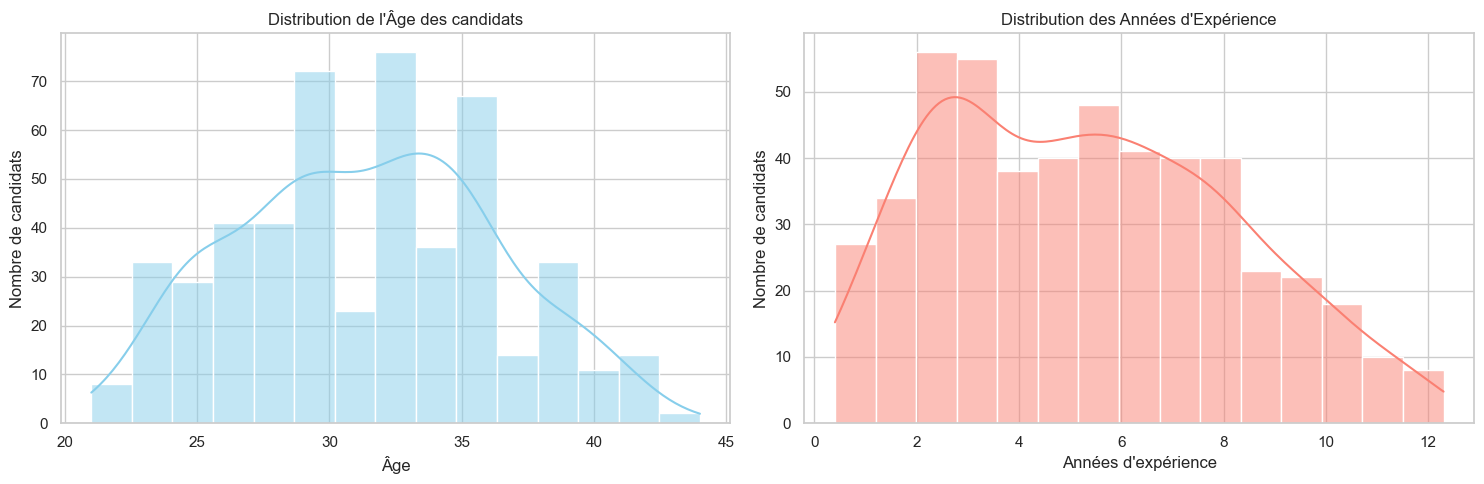

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution de l'âge
sns.histplot(df['age'], bins=15, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution de l'Âge des candidats")
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre de candidats")

# Distribution de l'expérience totale
sns.histplot(df['total_experience_years'], bins=15, kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Distribution des Années d'Expérience")
axes[1].set_xlabel("Années d'expérience")
axes[1].set_ylabel("Nombre de candidats")

plt.tight_layout()
plt.show()

## 4. Analyse Bivariée (Relations entre les variables)
Existe-t-il une corrélation forte entre l'âge et l'expérience ? Quels types de profils postulent pour quels rôles ?

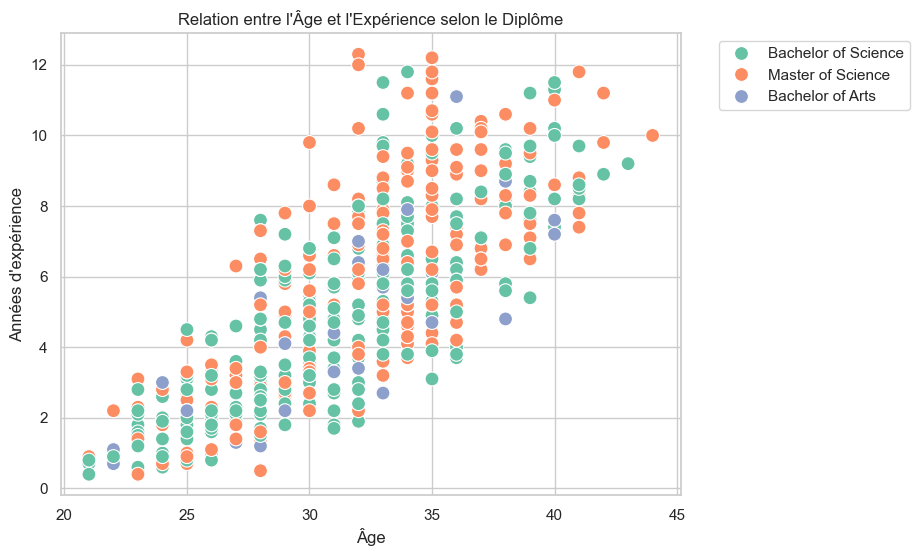

C:\Users\bourg\AppData\Local\Temp\ipykernel_12028\3502066684.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exp_by_role.values, y=exp_by_role.index, palette='viridis')


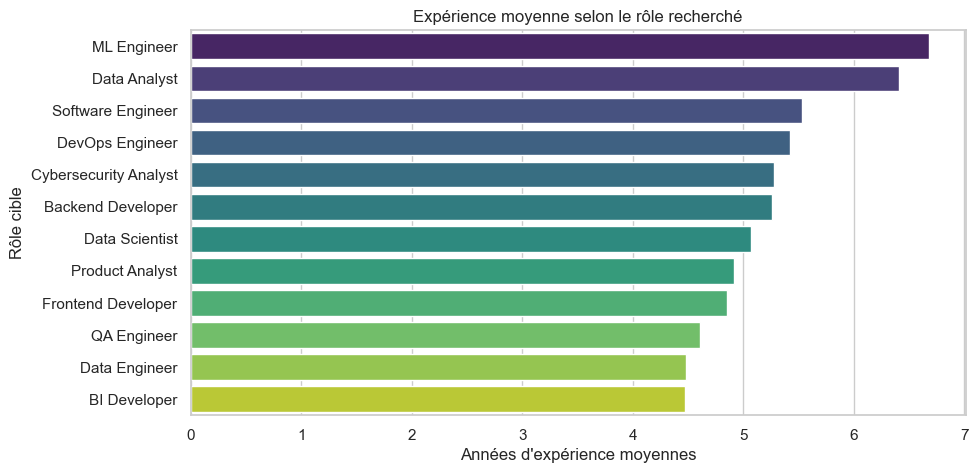

In [7]:
# Relation Âge vs Expérience
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='total_experience_years', hue='education_degree', s=100, palette='Set2')
plt.title("Relation entre l'Âge et l'Expérience selon le Diplôme")
plt.xlabel("Âge")
plt.ylabel("Années d'expérience")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Expérience moyenne par Rôle cible
plt.figure(figsize=(10, 5))
exp_by_role = df.groupby('target_role')['total_experience_years'].mean().sort_values(ascending=False)
sns.barplot(x=exp_by_role.values, y=exp_by_role.index, palette='viridis')
plt.title("Expérience moyenne selon le rôle recherché")
plt.xlabel("Années d'expérience moyennes")
plt.ylabel("Rôle cible")
plt.show()

## 5. Analyse des Compétences Linguistiques
Puisque le jeu de données contient des scores pour différentes langues (FR, EN, DE, LU, ES, IT), analysons le niveau linguistique global des candidats.

C:\Users\bourg\AppData\Local\Temp\ipykernel_12028\3130747538.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_langs.values, y=mean_langs.index, palette='magma')


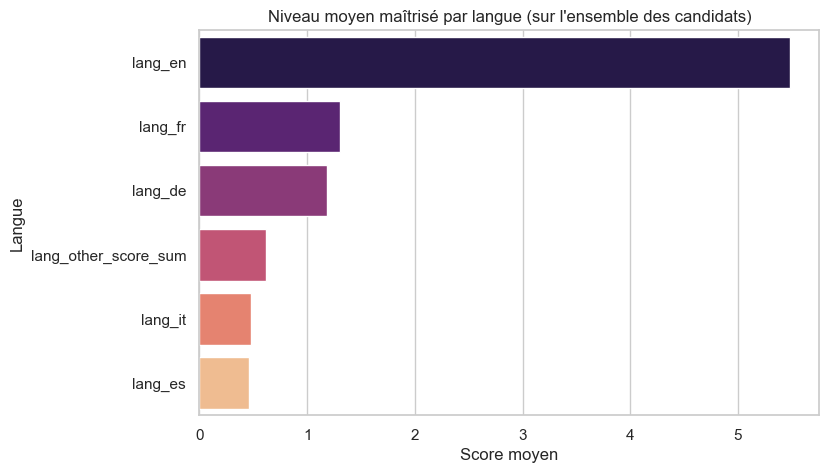

In [8]:
# Sélection des colonnes de langues
lang_cols = ['lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum']

# Calcul du niveau moyen pour chaque langue
mean_langs = df[lang_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=mean_langs.values, y=mean_langs.index, palette='magma')
plt.title("Niveau moyen maîtrisé par langue (sur l'ensemble des candidats)")
plt.xlabel("Score moyen")
plt.ylabel("Langue")
plt.show()

## 6. Analyse de la Matrice de Corrélation
Pour finir, nous pouvons générer une matrice de corrélation pour repérer mathématiquement les relations linéaires entre toutes nos variables numériques (ex: plus on est âgé, plus on habite loin ?).

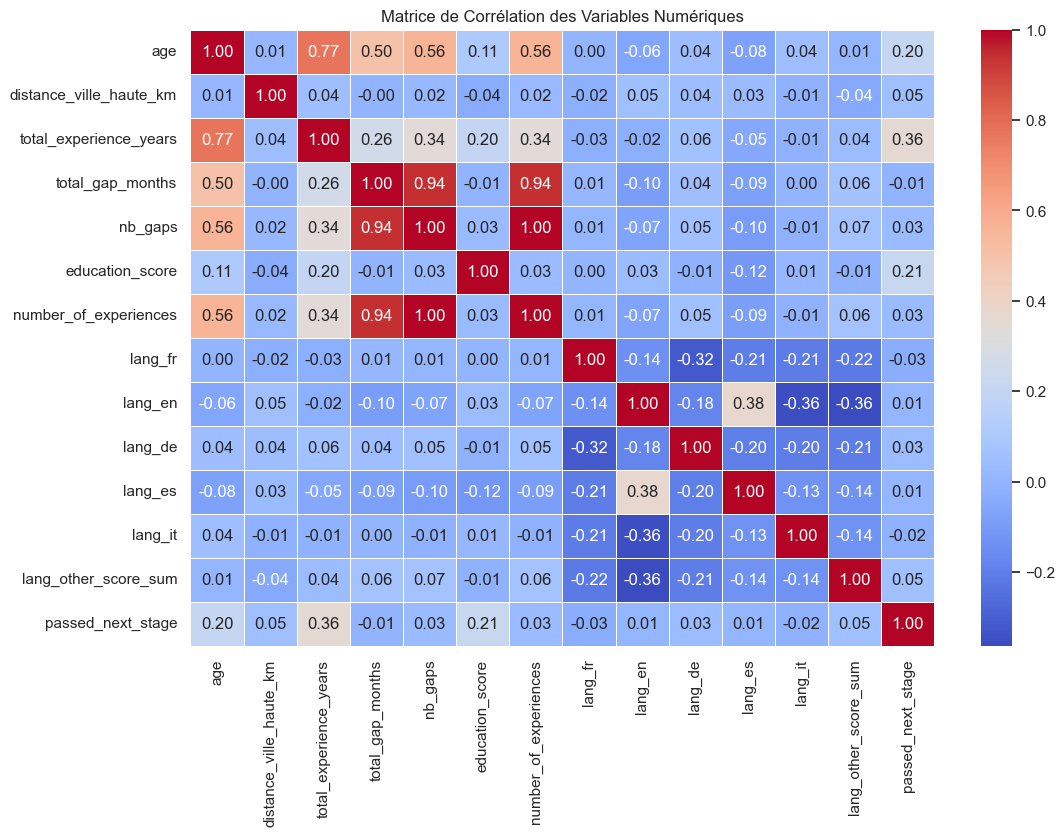

In [9]:
# Sélectionner uniquement les colonnes numériques
num_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
# Création d'une carte de chaleur (heatmap) des corrélations
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matrice de Corrélation des Variables Numériques")
plt.show()

## 7. Analyse de certaines distributions
Cela nous permettra de comprendre de différencié qui passe à l'étape suivante. Nous verrons si une variable influence vraiment la décision ainsi que les médianes et les outliers

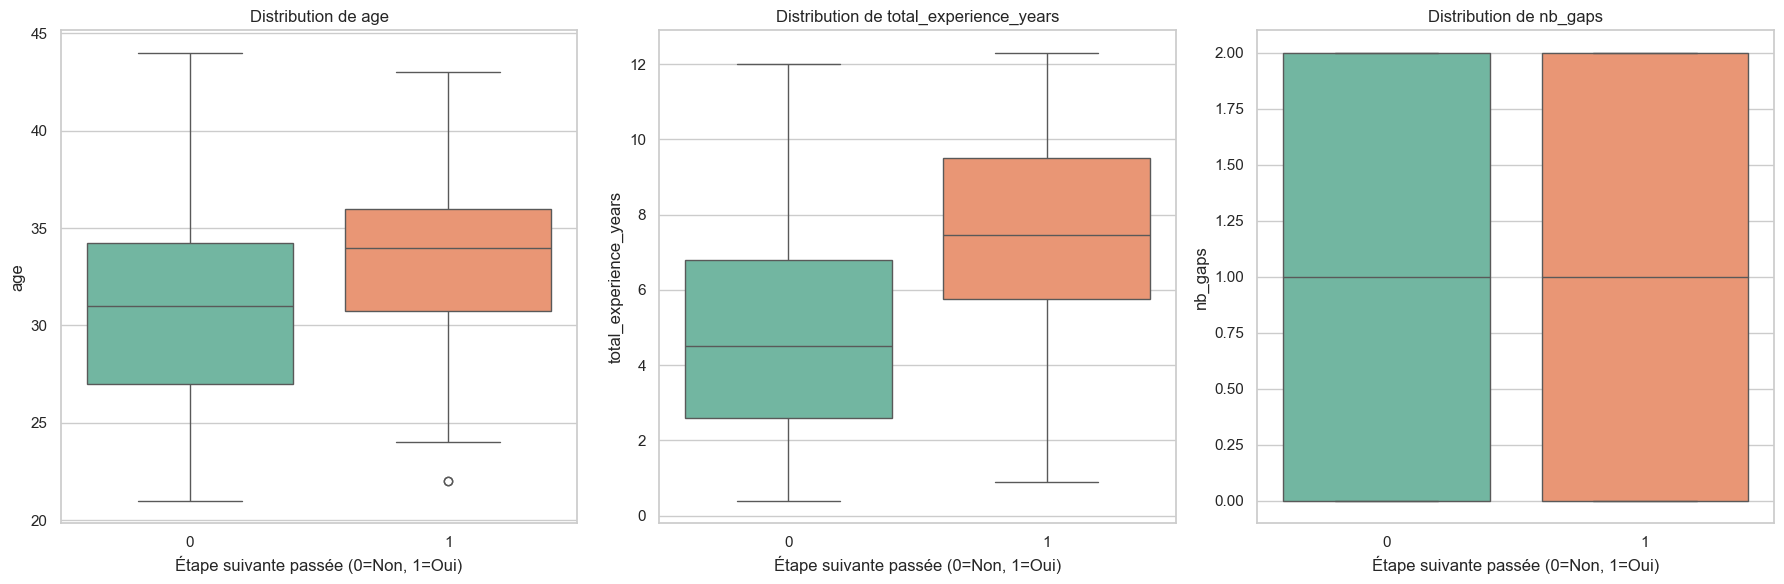

In [10]:
# Variables à analyser
features = ['age', 'total_experience_years', 'nb_gaps']
target = 'passed_next_stage'

# Création d'une figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(features):
    # Correction : on ajoute hue=target et legend=False pour éviter l'avertissement
    sns.boxplot(data=df, x=target, y=col, ax=axes[i], palette='Set2', hue=target, legend=False)

    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xlabel("Étape suivante passée (0=Non, 1=Oui)")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## 8.

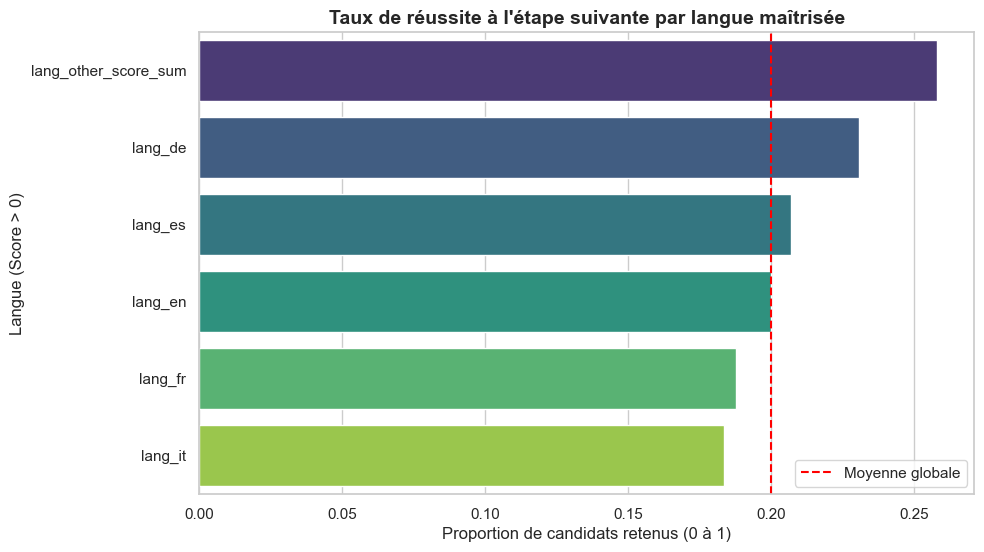

In [11]:
# 1. Liste des colonnes de langues à analyser
lang_cols = ['lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum']

# 2. Calcul du taux de succès pour chaque langue
# On considère qu'un candidat "maîtrise" la langue si son score est > 0
success_rates = {}
for lang in lang_cols:
    # Filtrer les candidats qui ont un score dans cette langue et calculer la moyenne de la cible
    rate = df[df[lang] > 0]['passed_next_stage'].mean()
    success_rates[lang] = rate

# Conversion en DataFrame pour le traçage
lang_df = pd.DataFrame(list(success_rates.items()), columns=['Langue', 'Taux_de_Succès'])
lang_df = lang_df.sort_values(by='Taux_de_Succès', ascending=False)

# 3. Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(
    data=lang_df,
    x='Taux_de_Succès',
    y='Langue',
    hue='Langue', # Pour la couleur
    palette='viridis',
    legend=False
)

# Ajout d'une ligne verticale pour le taux de succès moyen global (référence)
plt.axvline(df['passed_next_stage'].mean(), color='red', linestyle='--', label='Moyenne globale')

plt.title("Taux de réussite à l'étape suivante par langue maîtrisée", fontsize=14, fontweight='bold')
plt.xlabel("Proportion de candidats retenus (0 à 1)")
plt.ylabel("Langue (Score > 0)")
plt.legend()
plt.show()

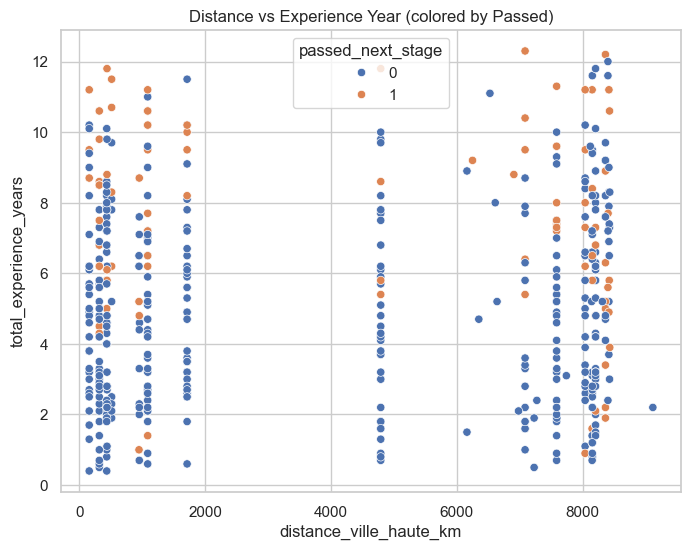

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="distance_ville_haute_km",
    y="total_experience_years",
    hue="passed_next_stage"
)

plt.title("Distance vs Experience Year (colored by Passed)")
plt.show()